Tutorial 4: Two Lens galaxies
=============================

Up to now, all the images we've fitted had one lens galaxy. However, we saw in chapter 1 that our lens plane can
consist of multiple galaxies which each contribute to the strong lensing. Multi-galaxy systems are challenging to
model, because they add an extra 5-10 parameters to the non-linear search and, more problematically, the degeneracies
between the parameters of the mass profiles of the two galaxies can be severe.

However, we can still break their analysis down using multiple searches and give ourselves a shot at getting a good
lens model. Here, we're going to fit a double lens system, fitting as much about each individual lens galaxy before
fitting them simultaneously.

Up to now, I've put a focus on an analysis being general. The script we write in this example is going to be the
opposite, specific to the image we're modeling. Fitting multiple lens galaxies is really difficult and writing a
pipeline that we can generalize to many lenses isn't currently possible.

In [1]:

%matplotlib inline
from pyprojroot import here
workspace_path = str(here())
%cd $workspace_path
print(f"Working Directory has been set to `{workspace_path}`")

from pathlib import Path
import autofit as af
import autolens as al
import autolens.plot as aplt

/Users/rosador/Documents/AGEL/autolens_workspace
Working Directory has been set to `/Users/rosador/Documents/AGEL/autolens_workspace`

***JAX ENABLED*** 
    
Using JAX for grad/jit and GPU/TPU acceleration. 
To disable JAX, set: config -> general -> jax -> use_jax = false
    
JAX mode enabled


__Initial Setup__

we'll use new strong lensing data, where:

 - There are two lens galaxy's whose `LightProfile`'s are both linear `Sersic`'s.
 - There are two lens galaxy's whose `MassProfile`'s are both `Isothermal`'s
 - The source galaxy's light is an `Exponential`.

In [2]:
dataset_name = "x2_lens_galaxies"
dataset_path = Path("dataset") / "imaging" / dataset_name

dataset = al.Imaging.from_fits(
    data_path=dataset_path / "data.fits",
    noise_map_path=dataset_path / "noise_map.fits",
    psf_path=dataset_path / "psf.fits",
    pixel_scales=0.05,
)

2025-10-29 12:20:52,696 - jax._src.xla_bridge - INFO - Unable to initialize backend 'cuda': 
2025-10-29 12:20:52,696 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-10-29 12:20:52,697 - jax._src.xla_bridge - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/autolens/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)


__Mask__

We need to choose our mask for the analysis. Given the lens light is present in the image we'll need to include all 
of its light in the central regions of the image, so lets use a circular mask. 

We'll use this mask in all four searches.

2025-10-29 12:20:53,285 - autoarray.dataset.imaging.dataset - INFO - Imaging data has been trimmed or padded for FFT convolution.
  - Original shape : (150, 150)
  - FFT shape    : (144, 144)
Padding ensures accurate PSF convolution in Fourier space. Set `disable_fft_pad=True` in Imaging object to turn off automatic padding.
2025-10-29 12:20:53,631 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 11304 image-pixels


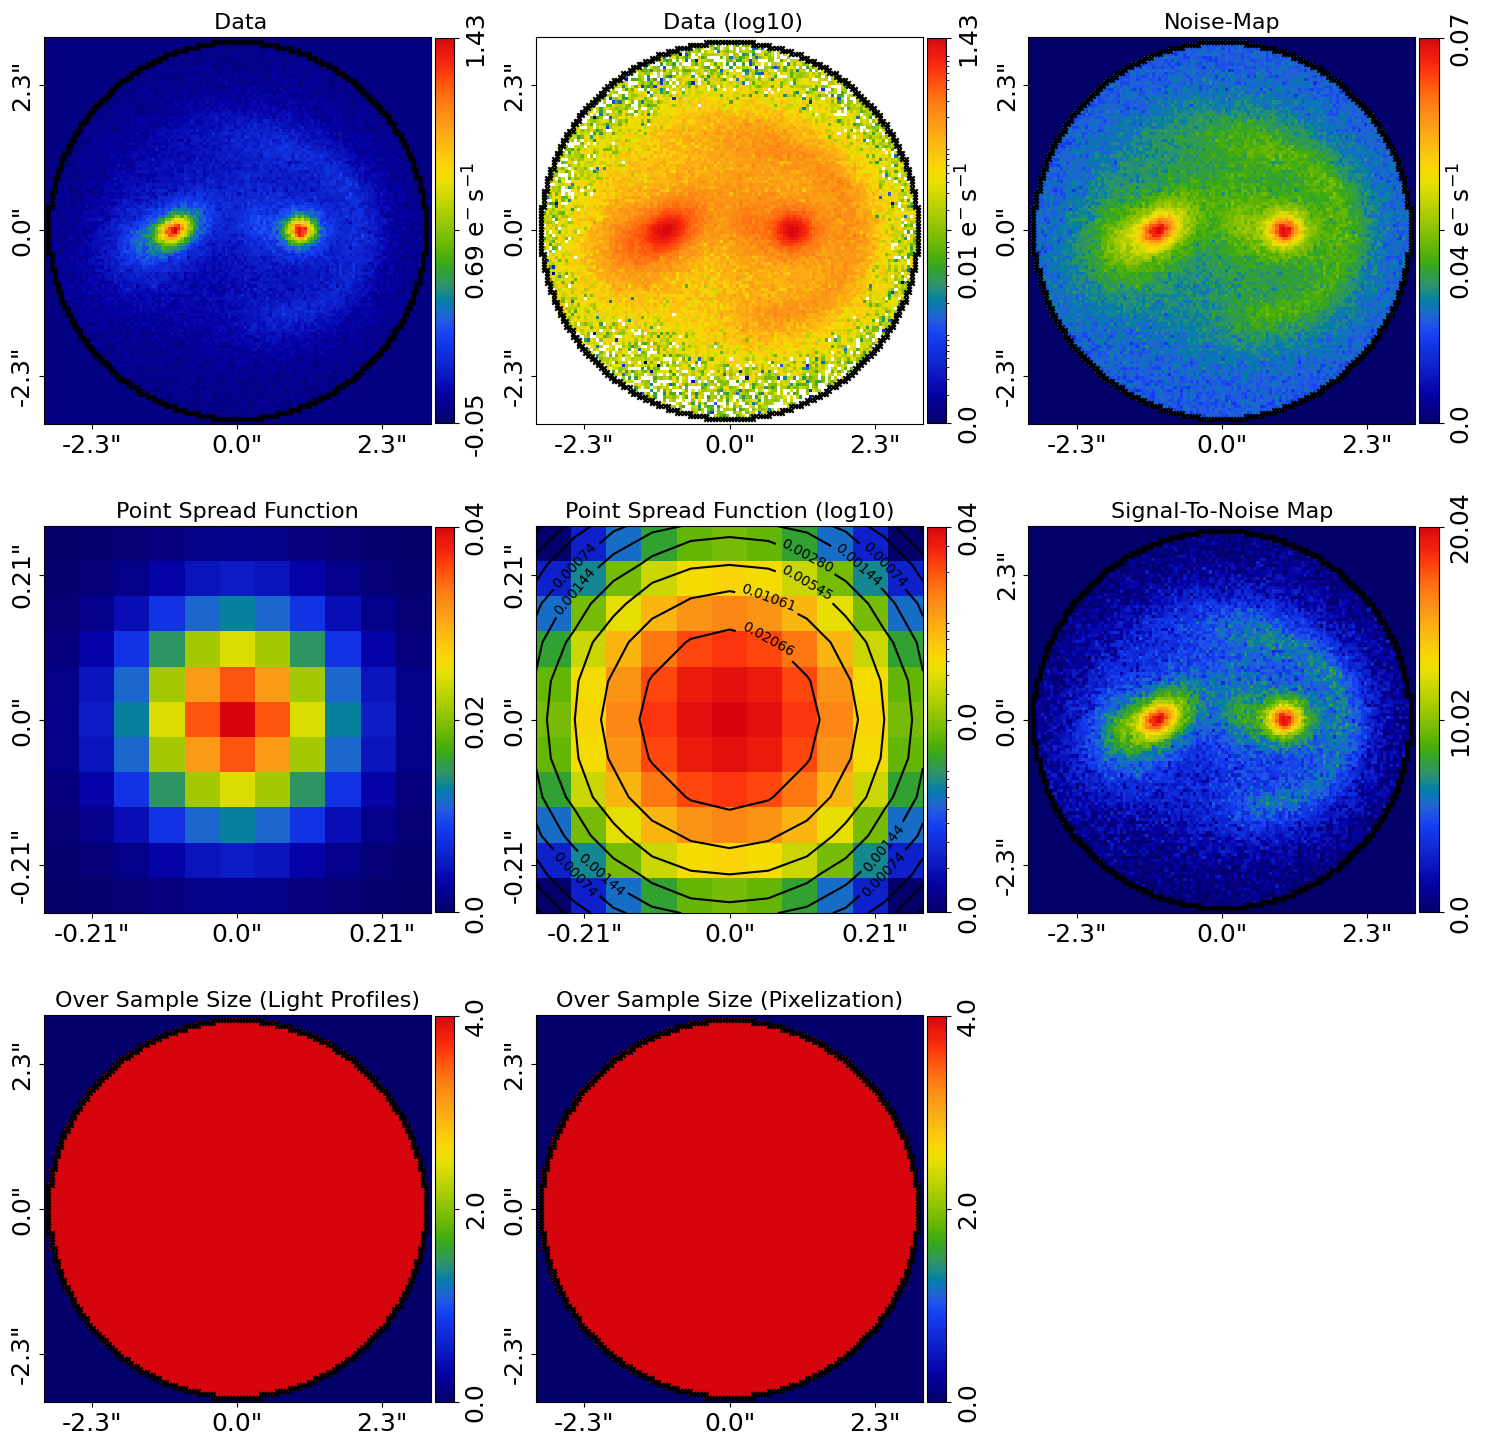

In [3]:
mask_radius = 3.0

mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=mask_radius,
)

dataset = dataset.apply_mask(mask=mask)

dataset_plotter = aplt.ImagingPlotter(
    dataset=dataset, visuals_2d=aplt.Visuals2D(mask=mask)
)
dataset_plotter.subplot_dataset()


__Paths__

All four searches will use the same `path_prefix`, so we write it here to avoid repetition.

In [4]:
path_prefix = Path("howtolens") / "chapter_3" / "tutorial_4_x2_lens_galaxies"

__Search Chaining Approach__

Looking at the image, there are two blobs of light corresponding to the two lens galaxies. The source's light is also 
pretty complex and the arcs don't posses the rotational symmetry we're used to seeing up to now. 
Multi-galaxy ray-tracing is just a lot more complicated, which means so is modeling it!

So, how can we break the lens modeling up? As follows:

 1) Fit and subtract the light of each lens galaxy individually.
 2) Use these results to initialize each lens galaxy's total mass distribution.

So, with this in mind, we'll perform an analysis using searches:

 1) Fit the light of the lens galaxy on the left of the image, at coordinates (0.0", -1.0").
 2) Fit the light of the lens galaxy on the right of the image, at coordinates (0.0", 1.0").
 3) Use this lens-subtracted image to fit the source's light. The mass profile centres of the two lens galaxies are 
 fixed to (0.0", -1.0") and (0.0", 1.0").
 4) Fit all relevant parameters simultaneously, using priors from searches 1, 2 and 3.

__Model + Search + Analysis + Model-Fit (Search 1)__

Search 1 fits a lens model where:

 - The left lens galaxy's light is a parametric linear `Sersic` bulge with a fixed centre [4 parameters].

 - The lens galaxy's mass and source galaxy are omitted.

The number of free parameters and therefore the dimensionality of non-linear parameter space is N=4.

We fix the centre of its light to (0.0, -1.0), the pixel we know the left galaxy's light centre peaks.

In [5]:
left_lens = af.Model(al.Galaxy, redshift=0.5, bulge=al.lp_linear.Sersic)
left_lens.bulge.centre_0 = 0.0
left_lens.bulge.centre_1 = -1.0

model_1 = af.Collection(galaxies=af.Collection(left_lens=left_lens))

The `info` attribute shows the model in a readable format.

In [6]:
print(model_1.info)

Total Free Parameters = 4

model                                                                           Collection (N=4)
    galaxies                                                                    Collection (N=4)
        left_lens                                                               Galaxy (N=4)
            bulge                                                               Sersic (N=4)

galaxies
    left_lens
        redshift                                                                0.5
        bulge
            centre
                centre_0                                                        0.0
                centre_1                                                        -1.0
            ell_comps
                ell_comps_0                                                     TruncatedGaussianPrior [2], mean = 0.0, sigma = 0.3, lower_limit = -1.0, upper_limit = 1.0
                ell_comps_1                                                     TruncatedG

__Search + Analysis + Model-Fit (Search 1)__

In [7]:
analysis_1 = al.AnalysisImaging(dataset=dataset)

search_1 = af.Nautilus(
    path_prefix=path_prefix,
    name="search[1]__left_lens_light[bulge]",
    unique_tag=dataset_name,
    n_live=75,
)

result_1 = search_1.fit(model=model_1, analysis=analysis_1)


2025-10-29 12:20:54,410 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.
2025-10-29 12:20:54,472 - search[1]__left_lens_light[bulge] - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/autolens_workspace/output/howtolens/chapter_3/tutorial_4_x2_lens_galaxies/x2_lens_galaxies/search[1]__left_lens_light[bulge]/6e87e60afafb3636be6be19821b03739
2025-10-29 12:20:54,473 - search[1]__left_lens_light[bulge] - INFO - Outputting pre-fit files (e.g. model.info, visualization).
2025-10-29 12:20:55,028 - search[1]__left_lens_light[bulge] - INFO - Starting new Nautilus non-linear search (no previous samples found).
2025-10-29 12:20:55,028 - autofit.non_linear.fitness - INFO - JAX: Applying vmap and jit to likelihood function -- may take a few seconds.
2025-10-29 12:20:55,028 - autofit.non_linear.fitness - INFO - JAX: vmap and jit applied in 0.0002582073211669922 seconds.
2025-10-29 12:20:55,029 - search[1]__left_lens_light[bulge] - INFO 

__Model + Search + Analysis + Model-Fit (Search 2)__

Search 2 fits a lens model where:

 - The left lens galaxy's light is a parametric linear `Sersic` bulge [0 parameters: fixed from search 1].

 - The right lens galaxy's light is a parametric linear `Sersic` bulge with a fixec centre [4 parameters].

 - The lens galaxy's mass and source galaxy are omitted.

The number of free parameters and therefore the dimensionality of non-linear parameter space is N=4.

We fix the centre of the right lens's light to (0.0, 1.0), the pixel we know the right galaxy's light centre peaks.

We also pass the result of the `left_lens` from search ` as an `instance`, which should improve the fitting of the
right lens.

In [8]:
right_lens = af.Model(al.Galaxy, redshift=0.5, bulge=al.lp_linear.Sersic)
right_lens.bulge.centre_0 = 0.0
right_lens.bulge.centre_1 = 1.0

model_2 = af.Collection(
    galaxies=af.Collection(
        left_lens=result_1.instance.galaxies.left_lens, right_lens=right_lens
    ),
)

analysis_2 = al.AnalysisImaging(dataset=dataset)

search_2 = af.Nautilus(
    path_prefix=path_prefix,
    name="search[2]__right_lens_light[bulge]",
    unique_tag=dataset_name,
    n_live=75,
)

result_2 = search_2.fit(model=model_2, analysis=analysis_2)

2025-10-29 12:21:22,076 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.
2025-10-29 12:21:22,101 - search[2]__right_lens_light[bulge] - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/autolens_workspace/output/howtolens/chapter_3/tutorial_4_x2_lens_galaxies/x2_lens_galaxies/search[2]__right_lens_light[bulge]/bb8716735f888fb684fad06b02f1b0ec
2025-10-29 12:21:22,101 - search[2]__right_lens_light[bulge] - INFO - Outputting pre-fit files (e.g. model.info, visualization).
2025-10-29 12:21:22,612 - search[2]__right_lens_light[bulge] - INFO - Starting new Nautilus non-linear search (no previous samples found).
2025-10-29 12:21:22,612 - autofit.non_linear.fitness - INFO - JAX: Applying vmap and jit to likelihood function -- may take a few seconds.
2025-10-29 12:21:22,612 - autofit.non_linear.fitness - INFO - JAX: vmap and jit applied in 0.00031375885009765625 seconds.
2025-10-29 12:21:22,613 - search[2]__right_lens_light[bulge] -

__Model + Search + Analysis + Model-Fit (Search 3)__

Search 3 fits a lens model where:

 - The left lens galaxy's light is a parametric linear `Sersic` bulge [0 parameters: fixed from search 1].

 - The right lens galaxy's light is a parametric linear `Sersic` bulge [0 parameters: fixed from search 2].

 - The lens galaxy's mass is modeled using two `Isothermal` profiles whose centres are fixed to (0.0, -1.0)
  and (0.0, 1.0) [6 parameters].
  
 - The source galaxy's light is a parametric linear `Exponential` [5 parameters].

The number of free parameters and therefore the dimensionality of non-linear parameter space is N=11.

In [9]:
left_lens = af.Model(
    al.Galaxy,
    redshift=0.5,
    bulge=result_1.instance.galaxies.left_lens.bulge,
    mass=al.mp.Isothermal,
)

right_lens = af.Model(
    al.Galaxy,
    redshift=0.5,
    bulge=result_2.instance.galaxies.right_lens.bulge,
    mass=al.mp.Isothermal,
)

left_lens.mass.centre_0 = 0.0
left_lens.mass.centre_1 = -1.0
right_lens.mass.centre_0 = 0.0
right_lens.mass.centre_1 = 1.0

model_3 = af.Collection(
    galaxies=af.Collection(
        left_lens=left_lens,
        right_lens=right_lens,
        source=af.Model(al.Galaxy, redshift=1.0, bulge=al.lp_linear.ExponentialCore),
    ),
)

analysis_3 = al.AnalysisImaging(dataset=dataset)

search_3 = af.Nautilus(
    path_prefix=path_prefix,
    name="search[3]__mass_x2[sie]__source[exp]",
    unique_tag=dataset_name,
    n_live=100,
)

result_3 = search_3.fit(model=model_3, analysis=analysis_3)

2025-10-29 12:21:54,594 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.
2025-10-29 12:21:54,621 - search[3]__mass_x2[sie]__source[exp] - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/autolens_workspace/output/howtolens/chapter_3/tutorial_4_x2_lens_galaxies/x2_lens_galaxies/search[3]__mass_x2[sie]__source[exp]/1b338a0d9a1df7bd6170b9c7bbc17a37
2025-10-29 12:21:54,621 - search[3]__mass_x2[sie]__source[exp] - INFO - Outputting pre-fit files (e.g. model.info, visualization).
2025-10-29 12:21:55,162 - search[3]__mass_x2[sie]__source[exp] - INFO - Starting new Nautilus non-linear search (no previous samples found).
2025-10-29 12:21:55,162 - autofit.non_linear.fitness - INFO - JAX: Applying vmap and jit to likelihood function -- may take a few seconds.
2025-10-29 12:21:55,163 - autofit.non_linear.fitness - INFO - JAX: vmap and jit applied in 0.00028896331787109375 seconds.
2025-10-29 12:21:55,163 - search[3]__mass_x2[sie]__sou

<Figure size 4400x4400 with 0 Axes>

__Model + Search + Analysis + Model-Fit (Search 4)__

Search 4 fits a lens model where:

 - The left lens galaxy's light is a parametric linear `Sersic` bulge [6 parameters: priors initialized from search 1].

 - The right lens galaxy's light is a parametric linear `Sersic` bulge [6 parameters: priors initialized from search 2].

 - The lens galaxy's mass is modeled using two `Isothermal` profiles whose centres are fixed to (0.0, -1.0)
  and (0.0, 1.0) [6 parameters: priors initialized from search 3].

 - The source galaxy's light is a parametric linear `Sersic` [6 parameters: priors initialized from search 3].

The number of free parameters and therefore the dimensionality of non-linear parameter space is N=24.

We don't explicitly check the run-time, but the same principles discussed above apply here.

In [10]:
left_lens = af.Model(
    al.Galaxy,
    redshift=0.5,
    bulge=result_1.model.galaxies.left_lens.bulge,
    mass=result_3.model.galaxies.left_lens.mass,
)

right_lens = af.Model(
    al.Galaxy,
    redshift=0.5,
    bulge=result_2.model.galaxies.right_lens.bulge,
    mass=result_3.model.galaxies.right_lens.mass,
)

source_bulge = af.Model(al.lp_linear.Sersic)

source_bulge.take_attributes(result_3.model.galaxies.source.bulge)

model_4 = af.Collection(
    galaxies=af.Collection(
        left_lens=left_lens,
        right_lens=right_lens,
        source=af.Model(al.Galaxy, redshift=1.0, bulge=source_bulge),
    ),
)

analysis_4 = al.AnalysisImaging(dataset=dataset)

search_4 = af.Nautilus(
    path_prefix=path_prefix,
    name="search[4]_light_x2[bulge]_mass_x2[sie]_source[exp]",
    unique_tag=dataset_name,
    n_live=100,
)

result_4 = search_4.fit(model=model_4, analysis=analysis_4)

2025-10-29 12:29:52,024 - autofit.non_linear.search.abstract_search - INFO - Starting non-linear search with 1 cores.
2025-10-29 12:29:52,051 - search[4]_light_x2[bulge]_mass_x2[sie]_source[exp] - INFO - The output path of this fit is /Users/rosador/Documents/AGEL/autolens_workspace/output/howtolens/chapter_3/tutorial_4_x2_lens_galaxies/x2_lens_galaxies/search[4]_light_x2[bulge]_mass_x2[sie]_source[exp]/4d623622e0b5128138bd9924b05ed02b
2025-10-29 12:29:52,052 - search[4]_light_x2[bulge]_mass_x2[sie]_source[exp] - INFO - Outputting pre-fit files (e.g. model.info, visualization).
2025-10-29 12:29:52,641 - search[4]_light_x2[bulge]_mass_x2[sie]_source[exp] - INFO - Starting new Nautilus non-linear search (no previous samples found).
2025-10-29 12:29:52,642 - autofit.non_linear.fitness - INFO - JAX: Applying vmap and jit to likelihood function -- may take a few seconds.
2025-10-29 12:29:52,642 - autofit.non_linear.fitness - INFO - JAX: vmap and jit applied in 0.0003712177276611328 seconds.

<Figure size 8000x8000 with 0 Axes>

__Wrap Up__

This pipeline takes a while to run, as is the nature of multi-galaxy modeling. Nevertheless, the techniques we've 
learnt above can be applied to systems with even more galaxies, albeit the increases in parameters will slow down the 
non-linear search. Here are some more Q&A`s

 1) This system had two very similar lens galaxy's with comparable amounts of light and mass. How common is this? 
 Does it make it harder to model them?

Typically, lenses with 2 galaxies have one massive galaxy (that makes up some 80%-90% of the overall light and mass), 
accompanied by a smaller satellite. The satellite cannotbe ignored, it impacts the ray-tracing in a measureable way, 
but it is a lot less degenerate with the main lens galaxy. This means we can often model the satellite with much 
simpler profiles (e.g. spherical profiles). So yes, multi-galaxy systems can often be easier to model.

 2) It got pretty confusing passing all those priors towards the end of the pipeline there, didn`t it?

It does get confusing. This is why we made galaxies named objects, so that we could call them the `left_lens` and 
`right_lens`. It still requires caution when writing the pipeline, but goes to show that if you name your galaxies 
sensibly you should be able to avoid errors, or spot them quickly when you make them.

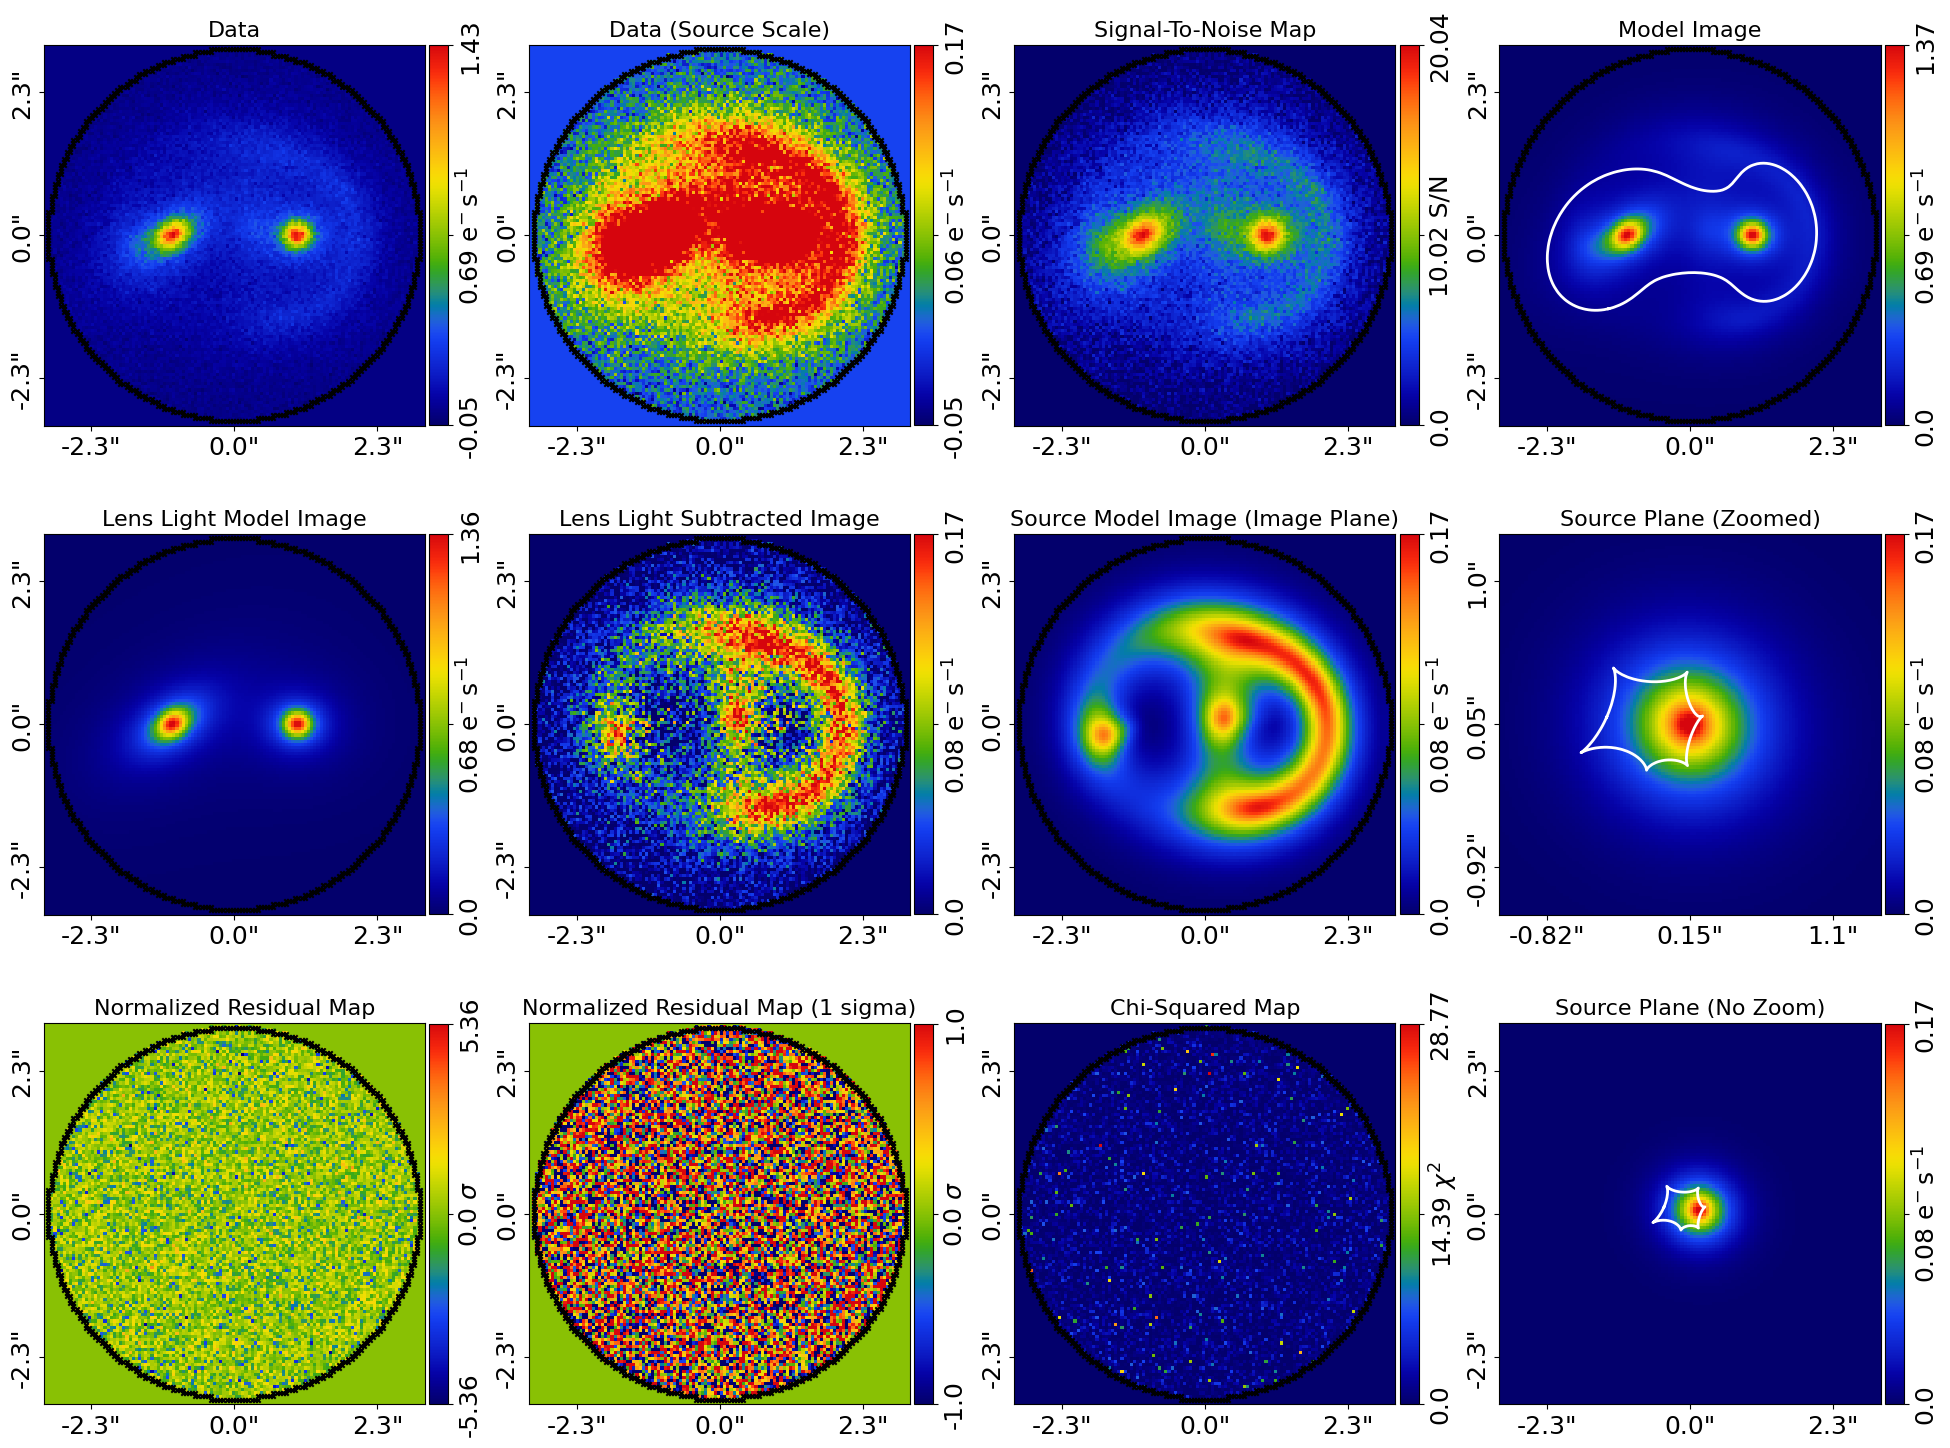

In [11]:
fit_plotter = aplt.FitImagingPlotter(fit=result_4.max_log_likelihood_fit)
fit_plotter.subplot_fit()

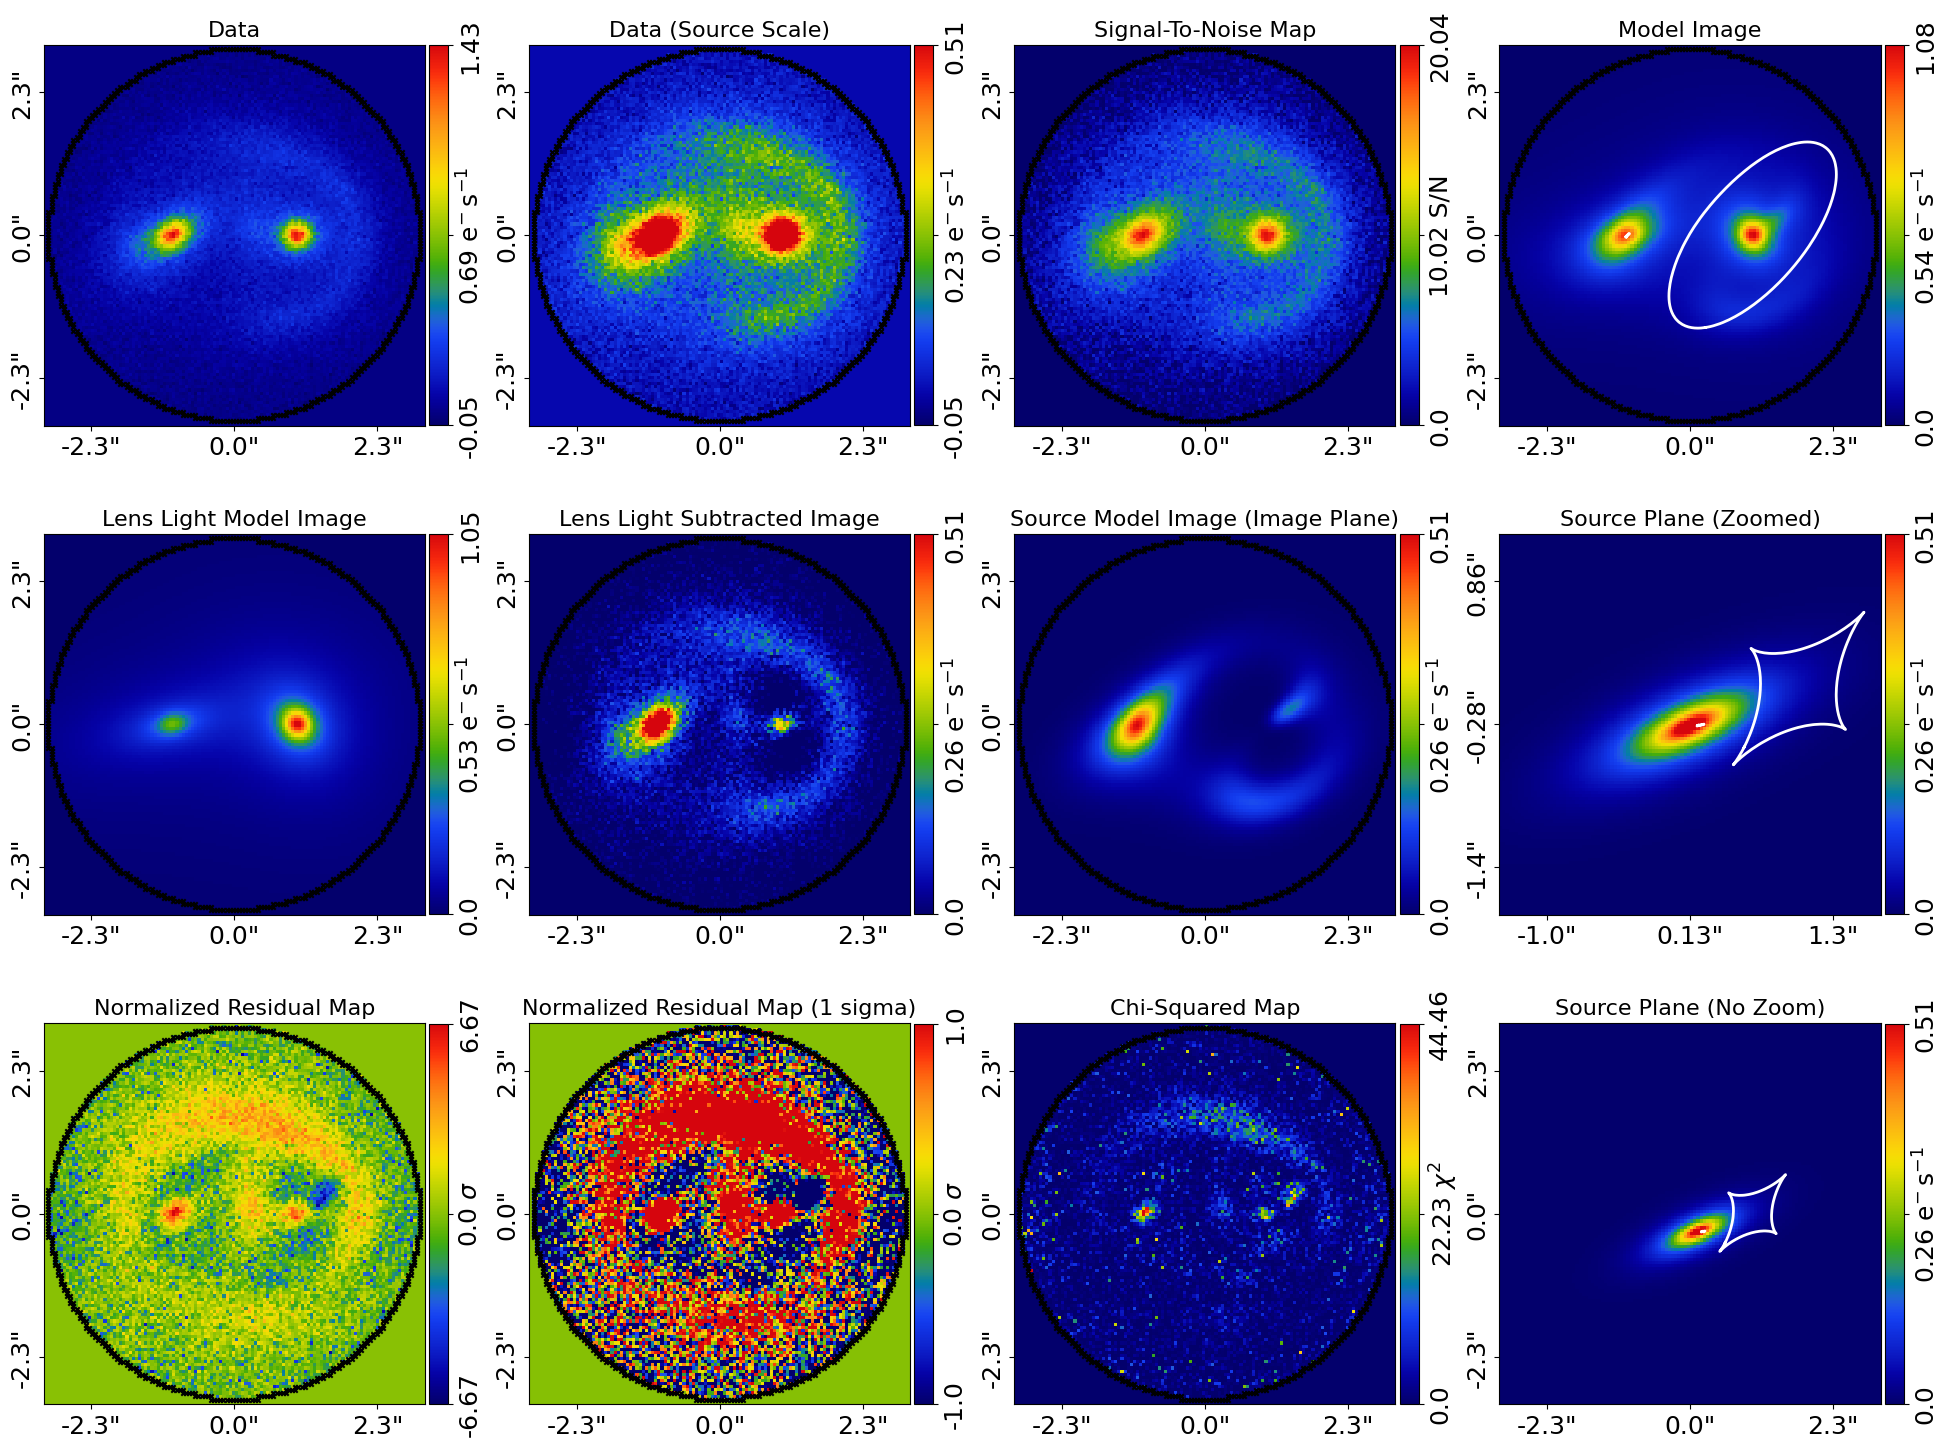

In [12]:
fit_plotter = aplt.FitImagingPlotter(fit=result_3.max_log_likelihood_fit)
fit_plotter.subplot_fit()

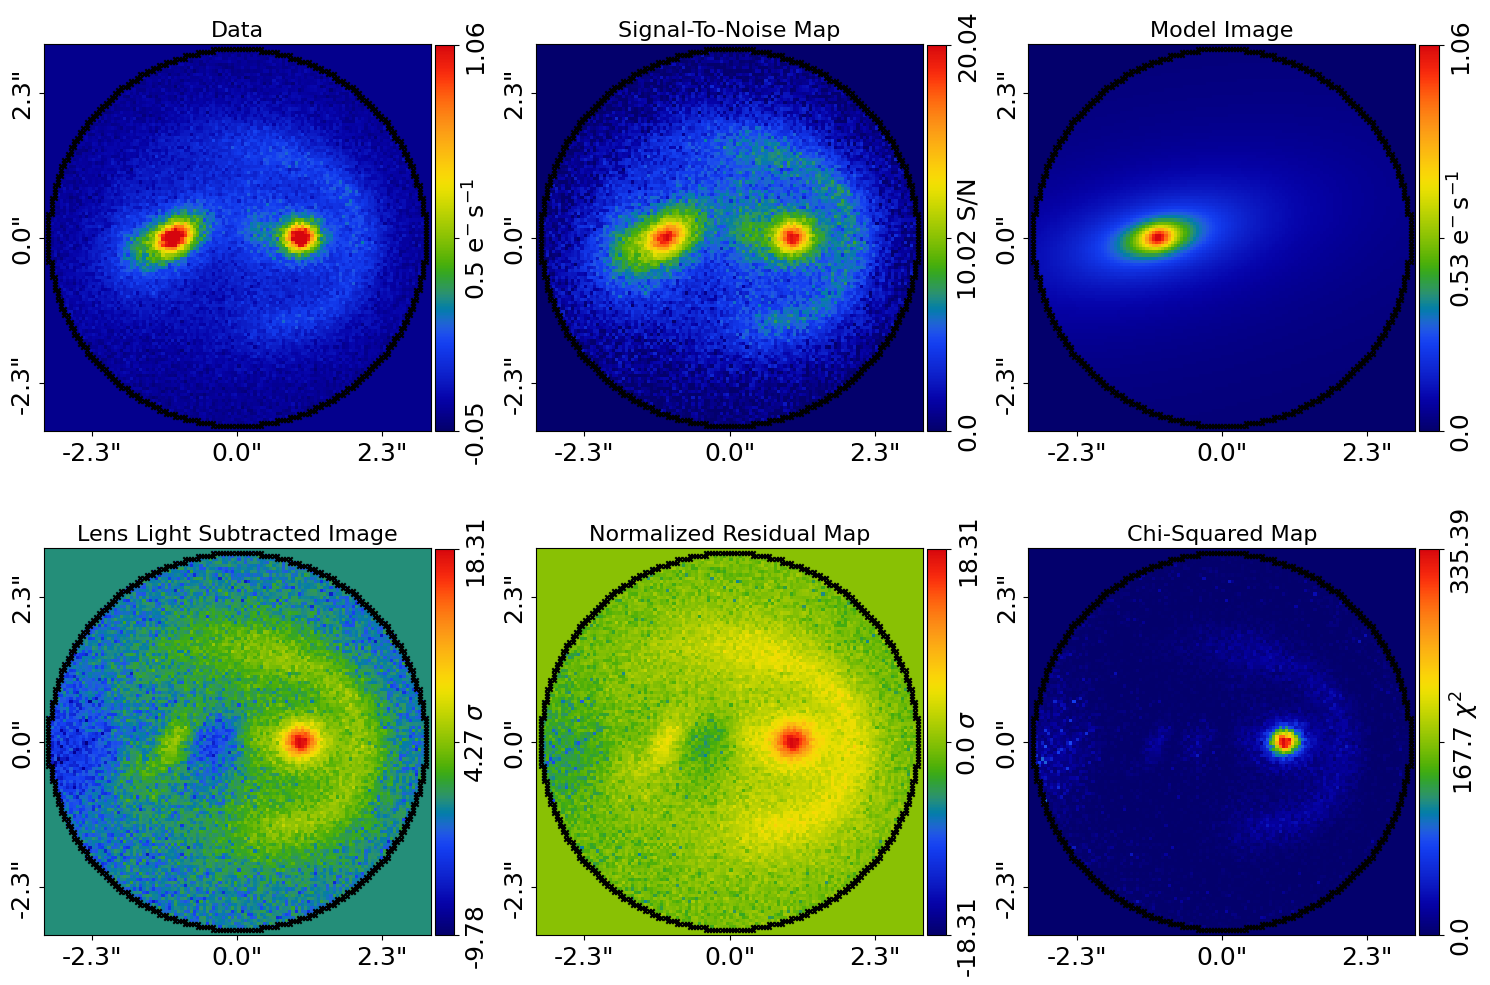

In [14]:
fit_plotter = aplt.FitImagingPlotter(fit=result_1.max_log_likelihood_fit)
fit_plotter.subplot_fit()